# 道路修復時間資料分析

1. **資料讀取**
   - 載入 `data/road_clean.csv`
   - 確認欄位與資料筆數

2. **探索性分析（EDA）**

   2.1 基本統計
   - 計算 `Duration (minutes)` 的 mean、median、std、min、max
   - 可觀察中位數遠小於平均值之重尾現象

   2.2 各災害種類的 Duration 統計
   - 以 `Cause` 為分組依據，計算各類別統計量

   2.3 Cause 分布統計
   - 計算各 Cause 類別的筆數與佔比，繪製圓餅圖

3. **高雄市 Cause 發生比例**
   - 篩選高雄市資料，計算各 Cause 發生比例
   - 資料來源為全台公路局養護路網，落石比例偏高，不能直接反映高雄市區的災害組成
   - 採用高雄市實際觀測的 Cause 比例作為後續模擬中災害類型發生機率之依據
   - 修復時間分布以全台資料擬合，保留完整重尾資訊

4. **CCDF 計算與繪製**
   - 以全台資料計算各 Cause 的經驗 CCDF：P(X > x)，以 log-log 尺度呈現
   - 作為後續分布擬合候選函式選定之依據

5. **多分布擬合（MLE + AIC）**
   - 以全台各 Cause 全量資料進行擬合，保留完整尾部資訊
   - 候選分布依據 CCDF 形狀決定
   - 以 MLE 估計參數，以 AIC 與 KS D 統計量作為模型選擇依據
   - 單一分布擬合效果不佳，尾部低估明顯，進一步採用 GMM 改善

6. **Gaussian Mixture Model（GMM）擬合**
   - 對 log(Duration) 進行 GMM 擬合，等同 Log-normal Mixture
   - 以 BIC 選定各 Cause 最佳 component 數
   - 以各 Cause Duration 進行離散化分層 (分為 5 層)，確保各層樣本數均衡且邊界由資料決定 ( data driven )
   - 以 Stratified K-Fold Cross-Validation 驗證模型泛化能力，並以各 fold log-likelihood 之 CV 量化穩定性


7. **相對誤差評估**
   - 以 GMM CCDF 估計值與經驗 CCDF 逐點計算相對誤差：$\dfrac{|F_{GMM} - F_{emp}|}{F_{emp}}$
   - 統計各 Cause 之中位數、平均數與最大相對誤差
   - 依相對誤差大小分為四級：< 5%（非常好）、5 ~ 10%（良好）、10 ~ 20%（尚可）、> 20%（偏差），統計相對誤差離散化後的分布表現

8. **成果存檔**
   - 高雄市各 Cause 發生比例
   - 各 Cause GMM 參數（weights、means、stds）
   - 統一寫入 `data/road_repair_params.json`

* **與電網資料不同處** : 依據高雄市區道路損壞原因的分佈機率，再依據該機率得出的修復時間分佈曲線做模擬 (在 第 3 節有較清楚的說明)，並採用 GMM 的 MLE 方式進行擬合

# 1. 資料讀取

In [184]:
import pandas as pd
import os

DATA_DIR = "data"

# 載入清理後的資料
df = pd.read_csv(os.path.join(DATA_DIR, "road_clean.csv"))

# 確認欄位與資料筆數
print(f"資料筆數：{len(df)}")
print(f"欄位：{df.columns.tolist()}")
df.head()

資料筆數：10289
欄位：['轄管局處段', '通報時間', '實際解除時間', '路線', '災害主次類別', '管制原因', 'Duration (minutes)', 'Duration (days)', 'Cause', 'year']


,轄管局處段,通報時間,實際解除時間,路線,災害主次類別,管制原因,Duration (minutes),Duration (days),Cause,year
0,交通部公路局 北區養護工程分局 復興工務段,2014-06-05 06:52:00,2014-06-05 09:00:00,省道台7線37K+700~37K+700,道路 道路落石,零星落石,128.0,0.1,Rockfall,2014
1,交通部公路局 北區養護工程分局 復興工務段,2014-06-06 20:40:00,2014-06-06 22:00:00,省道台7線35K+500~35K+500,道路 道路落石,零星落石,80.0,0.1,Rockfall,2014
2,交通部公路局 北區養護工程分局 復興工務段,2014-06-23 07:14:00,2014-06-23 09:55:00,省道台7線19K+500~19K+500,道路 道路落石,零星落石,161.0,0.1,Rockfall,2014
3,交通部公路局 雲嘉南區養護工程分局 阿里山工務段,2014-06-01 01:00:00,2014-06-01 03:00:00,省道台18線72K+500~72K+500,道路 道路落石,零星落石,120.0,0.1,Rockfall,2014
4,交通部公路局 雲嘉南區養護工程分局 阿里山工務段,2014-06-09 07:20:00,2014-06-09 09:20:00,省道台18線72K+500~72K+500,道路 道路落石,零星落石,120.0,0.1,Rockfall,2014


# 2. 探索性分析（EDA）

## 2.1 基本統計資料

* 紀錄道路封閉修復時間的 mean、median、std、min、max 等資訊
* 若中位數遠小於平均值，代表存在重尾現象，即極端事件拉高整體平均修復時間

In [185]:
# 2.1 基本統計
stats = df["Duration (minutes)"].agg(["mean", "median", "std", "min", "max"])
stats.index = ["Mean", "Median", "Std", "Min", "Max"]
stats.to_frame("Duration (minutes)").round(2)

,Duration (minutes)
Mean,490.62
Median,89.00
Std,6113.32
Min,0.42
Max,436409.75


## 2.2 各災害種類的 Duration 統計

In [186]:
# 各災害種類的 Duration 統計
cause_stats = df.groupby("Cause")["Duration (minutes)"].agg(["count", "mean", "median", "std", "min", "max"])
cause_stats.columns = ["Count", "Mean", "Median", "Std", "Min", "Max"]
cause_stats.round(2)

,Count,Mean,Median,Std,Min,Max
Cause,,,,,,
Natural Disaster,1219,2303.86,184.48,17261.82,1.03,436409.75
Other,1280,347.68,113.50,1318.46,0.42,20030.00
Rockfall,7790,230.37,71.00,1377.39,0.73,43260.00


## 2.3 Cause 分布統計

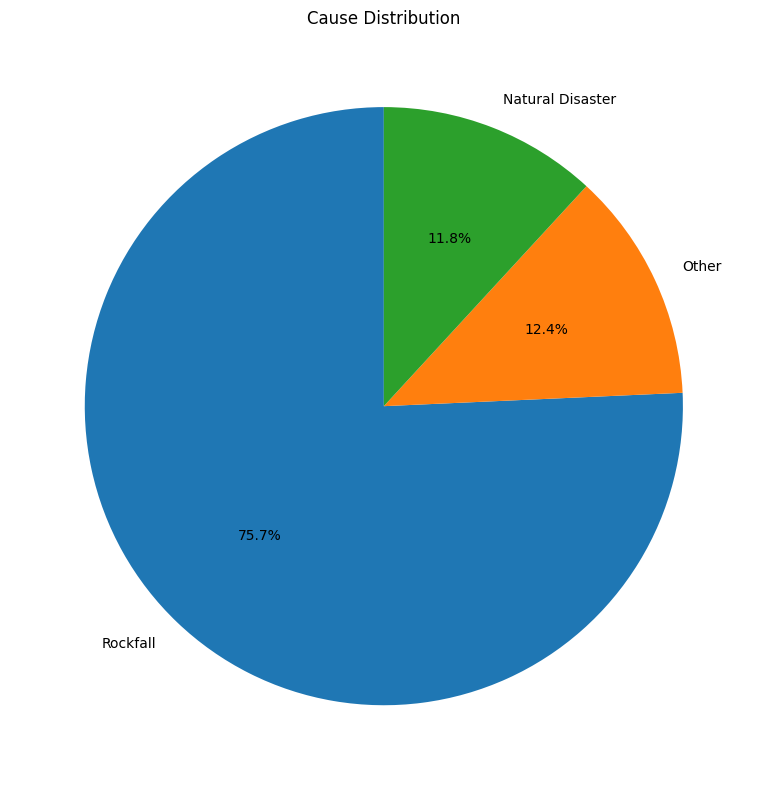

In [187]:
import matplotlib.pyplot as plt

cause_counts = df["Cause"].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(cause_counts, labels=cause_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Cause Distribution")
plt.tight_layout()
plt.show()

# 3. 高雄市 Cause 發生比例

由 EDA 可以發現落石的比例過高，主要原因為資料來源為公路總局，故資料集中在省道的部分，故山區落石造成道路中斷的機率較市區內較封閉的道路高很多，由於我們要分析高雄市區的道路損壞程度機率，但若採用分層取樣我會認為會無法處理重尾分佈的現象，因為髓機取樣取到重尾的機率很低，故不採用

後續採用，依據高雄市區道路損壞原因的分佈機率，再依據該機率得出的修復時間分佈曲線做模擬

## 3.1 高雄市道路事件分佈比例

In [188]:
# 篩選高雄市資料
df_kaohsiung = df[df["轄管局處段"].str.contains("高雄", na=False)].copy()
print(f"高雄市資料筆數：{len(df_kaohsiung)}")
print()

# 高雄 Cause 發生比例
kaohsiung_ratio = (
    df_kaohsiung["Cause"]
    .value_counts(normalize=True)
    .rename_axis("Cause")
    .reset_index(name="Ratio")
)
kaohsiung_ratio["Ratio"] = kaohsiung_ratio["Ratio"].round(4)
kaohsiung_ratio

高雄市資料筆數：187



,Cause,Ratio
0,Other,0.5775
1,Natural Disaster,0.2406
2,Rockfall,0.1818


Other 有點高，偷瞄一眼不分類實際分佈

In [189]:
# 高雄市 災害主次類別 分布
kh_detail = (
    df_kaohsiung["災害主次類別"]
    .value_counts()
    .rename_axis("災害主次類別")
    .reset_index(name="Count")
)
kh_detail["Pct (%)"] = (kh_detail["Count"] / len(df_kaohsiung) * 100).round(1)
kh_detail

,災害主次類別,Count,Pct (%)
0,道路 其他,92,49.2
1,道路 道路落石,34,18.2
2,道路 邊坡坍方,19,10.2
3,其他 其他,15,8.0
4,道路 土石流阻斷,14,7.5
5,道路 淹水,11,5.9
6,道路 路基流失,1,0.5
7,道路 交通事故(含危險品洩漏疑慮、火災),1,0.5


## 3.2 視覺化

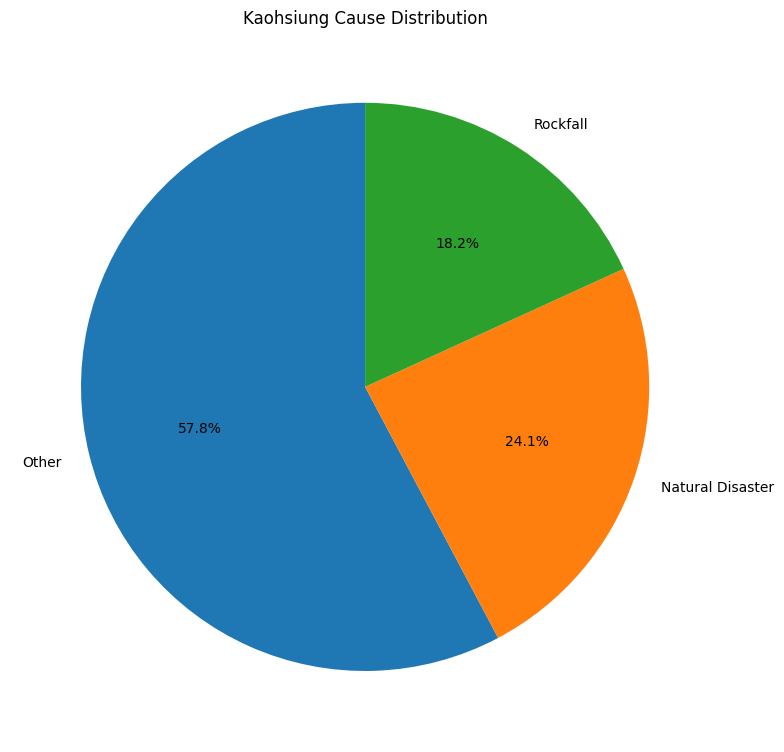

In [190]:
# 圓餅圖
kaohsiung_counts = df_kaohsiung["Cause"].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(kaohsiung_counts, labels=kaohsiung_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Kaohsiung Cause Distribution")
plt.tight_layout()
plt.show()

# 4. CCDF 計算與繪製

* 使用全台資料，依 Cause 分組繪製經驗 CCDF，以 log-log 尺度呈現，作為後續分布擬合候選函式選定之依據

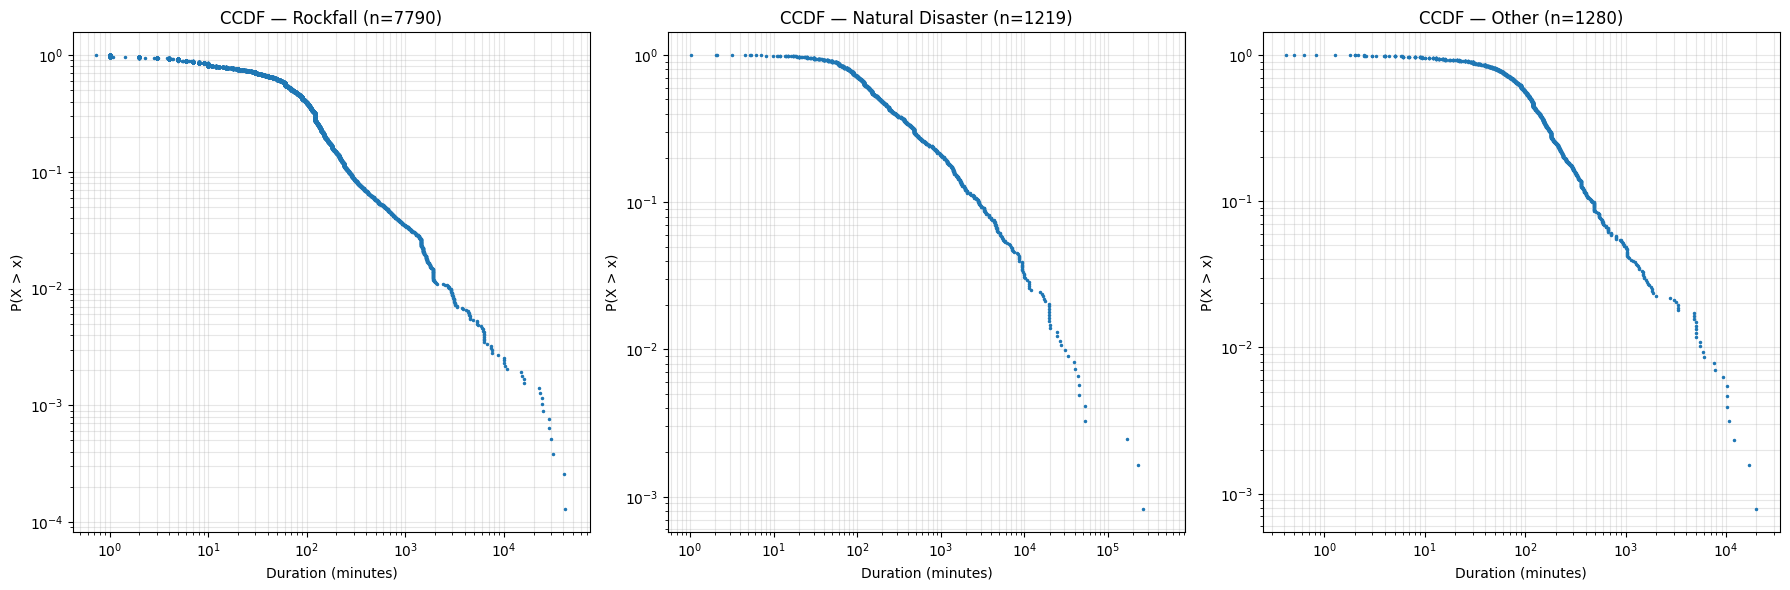

In [191]:
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()

causes = df["Cause"].unique()

for i, cause in enumerate(causes):
    data = np.sort(df[df["Cause"] == cause]["Duration (minutes)"].values)
    ccdf = 1 - np.arange(1, len(data) + 1) / len(data)

    axes[i].loglog(data, ccdf, marker=".", linestyle="none", markersize=3)
    axes[i].set_title(f"CCDF — {cause} (n={len(data)})")
    axes[i].set_xlabel("Duration (minutes)")
    axes[i].set_ylabel("P(X > x)")
    axes[i].grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

# 5. 多分布擬合（MLE + AIC）

* 各 Cause CCDF 觀察

  * **Rockfall / Natural Disaster / Other**
      
      三類別在 log-log 尺度下皆呈現明顯向下彎曲弧線，為典型 Log-normal 分布特徵，與電網修復時間資料之結論一致，顯示修復時間具有重尾特性，極端事件發生機率高於指數分布之預期


* 候選分布

    | Cause | 候選分布 |
    |---|---|
    | Rockfall | Log-normal、Weibull、Gamma、Burr (XII)、Gen. Pareto、Gen. Gamma |
    | Natural Disaster | Log-normal、Weibull、Gamma、Burr (XII)、Gen. Pareto、Gen. Gamma |
    | Other | Log-normal、Weibull、Gamma、Burr (XII)、Gen. Pareto、Gen. Gamma |


## 5.1 函式擬合

In [192]:
from scipy import stats

# 候選分布定義
candidates_main = {
    "Log-normal"  : stats.lognorm,
    "Weibull"     : stats.weibull_min,
    "Gamma"       : stats.gamma,
    "Burr (XII)"  : stats.burr,
    "Gen. Pareto" : stats.genpareto,
    "Gen. Gamma"  : stats.gengamma,
}


cause_candidates = {
    "Rockfall"         : candidates_main,
    "Natural Disaster" : candidates_main,
    "Other"            : candidates_main,
}

fit_results   = {}
fitted_params = {}

for cause, candidates in cause_candidates.items():
    data = np.sort(df[df["Cause"] == cause]["Duration (minutes)"].values)
    rows = []
    fitted_params[cause] = {}

    for name, dist in candidates.items():
        try:
            params  = dist.fit(data, floc=0)
            log_lik = np.sum(dist.logpdf(data, *params))
            k       = len(params)
            aic     = 2 * k - 2 * log_lik
            ks_d, _ = stats.kstest(data, lambda x: dist.cdf(x, *params))

            rows.append({"Distribution": name, "AIC": round(aic, 2), "KS D": round(ks_d, 4)})
            fitted_params[cause][name] = (dist, params)

        except Exception as e:
            print(f"[{cause}] {name} 擬合失敗：{e}")

    result_df = pd.DataFrame(rows).sort_values("AIC").reset_index(drop=True)
    fit_results[cause] = result_df
    print(f"=== {cause} (n={len(data)}) ===")
    print(result_df.to_string(index=False))
    print()

=== Rockfall (n=7790) ===
Distribution      AIC   KS D
  Burr (XII) 91144.41 0.0632
 Gen. Pareto 91305.49 0.0790
  Gen. Gamma 91672.05 0.0895
  Log-normal 91693.06 0.1112
     Weibull 92930.77 0.1156
       Gamma 95405.46 0.2024

=== Natural Disaster (n=1219) ===
Distribution      AIC   KS D
  Burr (XII) 18249.34 0.0588
 Gen. Pareto 18356.47 0.0891
  Log-normal 18385.71 0.1028
  Gen. Gamma 18524.62 0.1131
     Weibull 18885.74 0.1489
       Gamma 19517.51 0.2454

=== Other (n=1280) ===
Distribution      AIC   KS D
  Burr (XII) 16232.16 0.0535
 Gen. Pareto 16366.27 0.1054
  Log-normal 16381.87 0.0835
  Gen. Gamma 16434.81 0.0971
     Weibull 16810.87 0.1439
       Gamma 17156.85 0.2205



## 5.2 視覺化

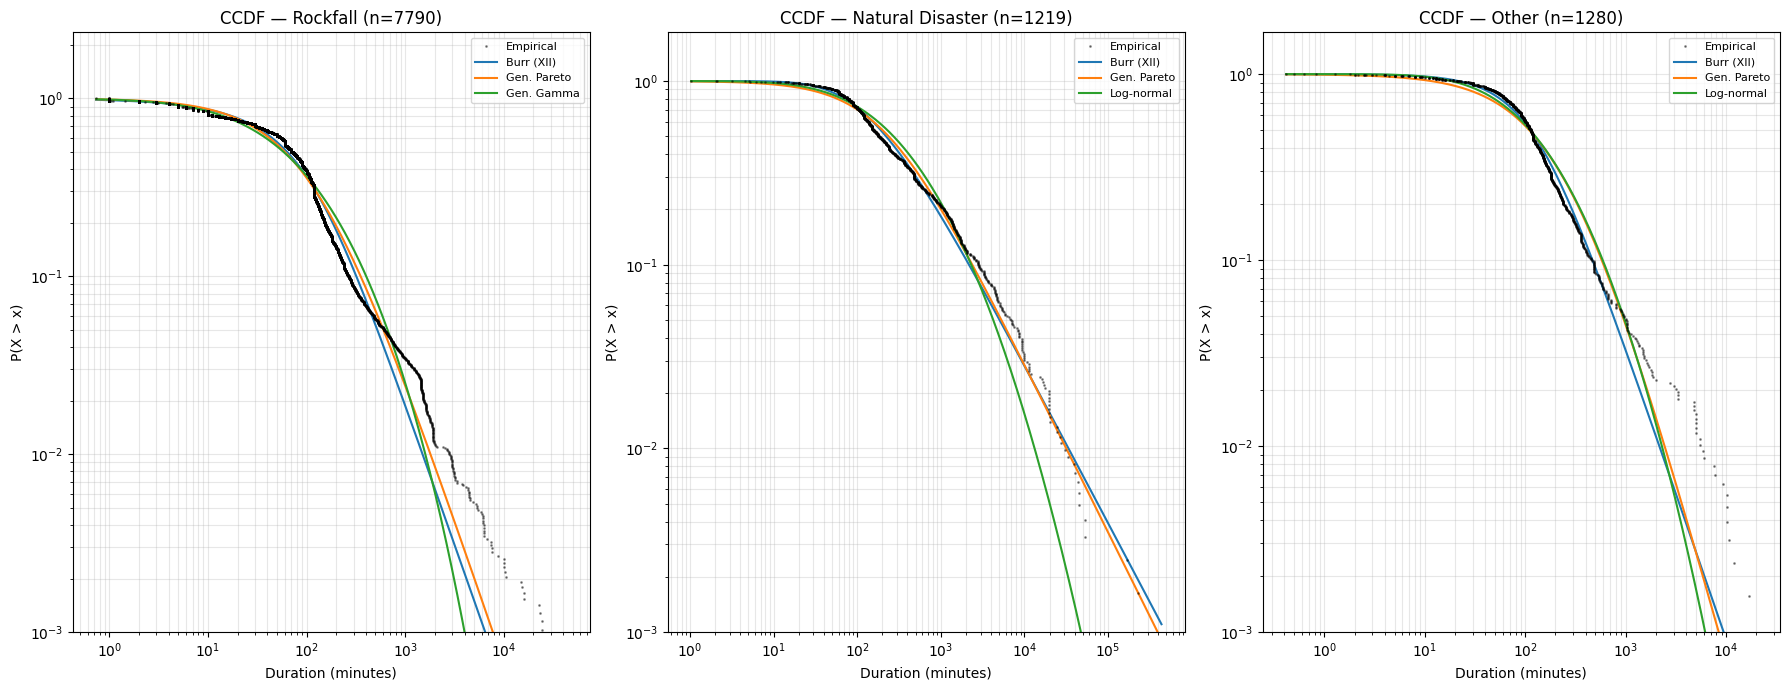

In [193]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
axes = axes.flatten()

colors = ["tab:blue", "tab:orange", "tab:green"]

for i, cause in enumerate(cause_candidates.keys()):
    data   = np.sort(df[df["Cause"] == cause]["Duration (minutes)"].values)
    ccdf   = 1 - np.arange(1, len(data) + 1) / len(data)
    x_plot = np.logspace(np.log10(data.min()), np.log10(data.max()), 600)

    ax = axes[i]

    # 實際 CCDF
    ax.loglog(data, ccdf, "k.", markersize=2, alpha=0.4, label="Empirical", zorder=5)

    # 依 AIC 取前三名
    top3 = fit_results[cause].head(3)["Distribution"].tolist()
    for name, color in zip(top3, colors):
        dist, params = fitted_params[cause][name]
        ccdf_th      = 1 - dist.cdf(x_plot, *params)
        ax.loglog(x_plot, ccdf_th, color=color, linewidth=1.5, label=name)

    ax.set_title(f"CCDF — {cause} (n={len(data)})")
    ax.set_xlabel("Duration (minutes)")
    ax.set_ylabel("P(X > x)")
    ax.set_ylim(bottom=1e-3)
    ax.legend(fontsize=8)
    ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

# 6. Gaussian Mixture Model（GMM）

* 因為擬合實在太醜了，改用 ML 方式處理

1. 基本概念

    GMM 是一種機率模型，假設資料是由多個高斯分布（常態分布）疊加而成，每個高斯分布代表一個「子族群」，整體分布是這些子族群的加權總和。

    此處對 $y = \log(\text{Duration})$ 進行 GMM 擬合，等同於對原始修復時間建立
    **Log-normal Mixture Model**，整體密度函數為：

    $$p(y) = \sum_{k=1}^{K} \pi_k \cdot \mathcal{N}(y \mid \mu_k, \sigma_k^2)$$

      &nbsp;

      | 符號 | 意義 |
      | :---: | :--- |
      | $K$ | component 數（子族群數量） |
      | $\pi_k$ | 第 $k$ 個 component 的權重（$\sum_{k=1}^{K} \pi_k = 1$） |
      | $\mu_k$ | 第 $k$ 個 component 在對數尺度上的平均值（即 $\log(\text{Duration})$ 的均值） |
      | $\sigma_k^2$ | 第 $k$ 個 component 在對數尺度上的變異數 |

      &nbsp;

      * 概念上類似於：事件發生機率由多個子族群模型疊加而成（乘上各族群權重後加總），有點類似於集成模型
        參數為各族群在對數尺度上的平均值與標準差。

      * 每個 component 對應一種修復情境，對應到原始 Duration 尺度如下，請注意並非代表切分區間，而是不同對數常態分佈適合不同種的情境，最後的機率密度都是3種模型疊加而成的：

        &nbsp;

        | Component | 物理意義 | Duration 範圍 |
        | :---: | :--- | :---: |
        | 短期 | 零星落石清除、輕微事故 | $< 2$ 小時 |
        | 中期 | 中規模坍方、道路修復 | $2$ 小時 $\sim 1$ 天 |
        | 長期 | 大規模災害、結構性修復 | $> 1$ 天 |

        &nbsp;

2. 參數估計：EM 演算法 : 
  
    * 迭代更新參數 $\mu_k$, $\sigma_k^2$, $\pi_k$

      GMM 透過 **Expectation-Maximization（EM）演算法** 估計參數，核心思路是：
      將「每個資料點屬於哪個 component」視為隱變數，反覆在「推測歸屬」與「更新參數」
      之間迭代，直到 log-likelihood 收斂。

    * E step（期望步）: 計算點位由機率密度個別模型的貢獻

      固定當前參數，計算每個資料點 $y_i$ 屬於第 $k$ 個 component 的
      **責任度（responsibility）**：

        $$r_{ik} = \frac{\pi_k \cdot \mathcal{N}(y_i \mid \mu_k, \sigma_k^2)}
        {\displaystyle\sum_{j=1}^{K} \pi_j \cdot \mathcal{N}(y_i \mid \mu_j, \sigma_j^2)}$$

        $r_{ik} \in [0, 1]$，且 $\sum_{k} r_{ik} = 1$，代表該資料點「分配」給各 component 的軟性比例。

    * M step（最大化步）

      固定責任度，以加權方式更新各 component 的參數：

      $$\mu_k = \frac{\displaystyle\sum_{i=1}^{n} r_{ik} \, y_i}{\displaystyle\sum_{i=1}^{n} r_{ik}}
      \qquad
      \sigma_k^2 = \frac{\displaystyle\sum_{i=1}^{n} r_{ik}(y_i - \mu_k)^2}
      {\displaystyle\sum_{i=1}^{n} r_{ik}}
      \qquad
        = \frac{\displaystyle\sum_{i=1}^{n} r_{ik}}{n}$$
      
    * 迭代過程
    
      ```bash 
      初始化 πₖ, μₖ, σₖ
           ↓
      E-step：πₖ, μₖ, σₖ → 算出 rᵢₖ
           ↓
      M-step：rᵢₖ → 更新 πₖ, μₖ, σₖ
           ↓
      E-step：新的 πₖ, μₖ, σₖ → 算出新的 rᵢₖ
           ↓
      M-step：新的 rᵢₖ → 再更新 πₖ, μₖ, σₖ
           ↓
       ...
      ```

    * 簡單來說 : 就是透過不同數量、不同參數的分佈曲線疊加計算樣本資料對模型的 對數相似度 (log-likelihood)，接著透過更新參數 ($\mu$, $\sigma^2$, $K$ 等)迭代 對數相似度直至收斂，則得到這組數量與參數對於樣本資料的相似度近似最大值，即擬合完成。
      
      * 注意喔! 是樣本資料對模型的相似度，將樣本資料丟到現有模型，如果許多模型的對數常態分佈對於這個值的相似度都很低，這個結果就是不好的，就需要迭代更新，可以想像成模型是鐘型曲線，結果拿著 2 倍標準差外的資料給他，此時就是相似度不好，就要改變模型的參數，也就是 $\mu$, $\sigma^2$ ，讓他去靠近這個值，而當樣本資料點位密度高時，迭代方向的趨勢就會更明顯
    
    * 收斂條件

      重複 E step → M step，直到相鄰兩次迭代的 log-likelihood 變化量小於門檻值
      $\epsilon$（目前採用 scikit-learn 預設值 $\epsilon = 10^{-3}$）：

      $$\left| \log\mathcal{L}^{(t+1)} - \log\mathcal{L}^{(t)} \right| < \epsilon$$

      $$\mathcal{L} = \sum_{i=1}^{n} \log \left[ \sum_{k=1}^{K} \pi_k \cdot \mathcal{N}(\log x_i \mid \mu_k, \sigma_k^2) \right]$$

      > **注意**：EM 演算法只保證收斂至**局部最佳解**，對初始值敏感。
      > 故採用 `n_init = 10`，以多組隨機初始值取最佳結果降低此風險。

&nbsp;

3. 模型選擇：BIC
    * 以 **BIC（Bayesian Information Criterion）** 選擇最佳 component 數 $K$，BIC 在 log-likelihood 的基礎上對參數數量進行懲罰，避免過擬合（數值越小代表模型越佳）：

    $$\text{BIC} = k \ln(n) - 2\ln(\hat{L})$$

      &nbsp;

      | 符號 | 意義 | 在本研究中 |
      | :---: | :--- | :--- |
      | $k$ | 模型的自由參數數量 | 每個 component 有 3 個參數（$\pi_k$、$\mu_k$、$\sigma_k^2$），故 $k = 3K - 1$（權重加總為 1，少一個自由度） |
      | $n$ | 資料筆數 | 各 Cause 的樣本數 |
      | $\hat{L}$ | 最大化後的 likelihood | EM 收斂後模型對全量資料的擬合程度，即 $\prod_{i=1}^{n} p(y_i \mid \hat{\theta})$ |

      &nbsp;

    * 搜索範圍為 $K \in \{1, 2, \ldots, K_{\max}\}$，取 BIC 最小的 $K$ 作為最終 component 數。

&nbsp;

4. 模型泛化能力評估：Stratified K-Fold

    * 動機

      由於修復時間具有重尾特性，極端事件佔比極少，若使用隨機 K-Fold 取樣，
      test fold 可能完全不含尾部資料，無法有效評估尾部擬合品質。

    * 做法

      採用 **Stratified K-Fold**：

      1. 採用分層取樣，將樣本資料分五等分，每 fold 抽該區間的 1/K
      2. 取 $K_{\text{fold}} = 5$，即每次以 80% 訓練、20% 測試

&nbsp;

5. 模型泛化能力評估：Log-likelihood

     * 評估邏輯

       K-Fold 切分了不同的 test 資料集，為了確認模型泛化能力，將訓練集擬合的參數
       $\hat{\theta}$ 固定，對各 fold 的 test 集分別計算 log-likelihood，
       **觀察各 fold 之間的數值是否穩定一致**。若波動過大，代表模型對資料子集敏感，
       泛化能力不足。

     * 公式

       對於 Log-normal Mixture，test fold 中資料點 $y_i = \log(\text{Duration}_i)$ 的 likelihood 為：

       $$\mathcal{L}(\theta) = \prod_{i=1}^{n} p(y_i \mid \theta)
       = \prod_{i=1}^{n} \sum_{k=1}^{K} \pi_k \cdot \mathcal{N}(y_i \mid \mu_k, \sigma_k^2)$$

       取對數後轉為加法形式：

       $$\log \mathcal{L}(\theta) = \sum_{i=1}^{n} \log
       \left( \sum_{k=1}^{K} \pi_k \cdot \mathcal{N}(y_i \mid \mu_k, \sigma_k^2) \right)$$

     * 標準化：per-sample log-likelihood

       由於各 fold 的樣本數 $n$ 不同，直接比較 $\log\mathcal{L}$ 會受樣本數影響。
       因此採用**每樣本平均 log-likelihood** 作為比較基準：

       $$\overline{\log\mathcal{L}} = \frac{1}{n} \log \mathcal{L}(\theta)$$

     * 判讀標準

       計算 5 個 fold 的 ${\log\mathcal{L}}$ 後，以變異係數 CV 是否 < 5% 視作穩定：

       若各 fold 的 ${\log\mathcal{L}}$ 彼此差距過大（CV 偏高），代表模型過擬合於特定資料子集(可能是因族群數設定過高導致過擬合的原因)，需重新審視 component 數或資料前處理。

## 6.1 Duration 離散化分層

In [194]:
import numpy as np
import pandas as pd

# Traffic Accident 排除（樣本過少）
causes_fit = ["Rockfall", "Natural Disaster", "Other"]

# 各 Cause 獨立計算分位數邊界
df["duration_bin"] = np.nan

for cause in causes_fit:
    mask = df["Cause"] == cause
    # 建立 修復時間區間欄位 : 依據修復時間歸類為 q 等分
    df.loc[mask, "duration_bin"] = pd.qcut(
        df.loc[mask, "Duration (minutes)"],
        q=5,
        labels=False,
        duplicates="drop"
    )

# 確認分層分布
for cause in causes_fit:
    data_cause = df[df["Cause"] == cause]
    print(f"=== {cause} ===")
    # 計算該區間分類數量
    bin_count = data_cause["duration_bin"].value_counts().sort_index()
    bin_pct   = (bin_count / len(data_cause) * 100).round(1)
    display(pd.DataFrame({"Count": bin_count, "Pct (%)": bin_pct}))
    print()

=== Rockfall ===


,Count,Pct (%)
duration_bin,,
0.0,1561,20.0
1.0,1579,20.3
2.0,1535,19.7
3.0,1563,20.1
4.0,1552,19.9



=== Natural Disaster ===


,Count,Pct (%)
duration_bin,,
0.0,244,20.0
1.0,244,20.0
2.0,243,19.9
3.0,246,20.2
4.0,242,19.9



=== Other ===


,Count,Pct (%)
duration_bin,,
0.0,256,20.0
1.0,259,20.2
2.0,256,20.0
3.0,254,19.8
4.0,255,19.9


## 6.2 模型擬合與超參數 K 選擇

* 對 n_components 由 1~10 進行窮舉搜尋，後以 BIC 作為模型選擇準則，取 BIC 最小者作為最佳 component 數

In [195]:
from sklearn.mixture import GaussianMixture

# 使用 BIC 指標找出各 Cause 最佳 component 數量 function 
def fit_gmm(data, max_components=10):
    log_data   = np.log(data).reshape(-1, 1)
    best_gmm   = None
    best_bic   = np.inf
    bic_scores = []

    # 根據不同族群 n (component) 計算 BIC 指標
    for n in range(1, max_components + 1):
        gmm = GaussianMixture(
            n_components=n,
            random_state=42,
            max_iter=500,     # 最大迭代次數
            tol=1e-3,         # 收斂判斷
            n_init=5          # 多起點初始化，避免 EM 卡在局部最優
        )
        gmm.fit(log_data)

        # 判斷是否收斂
        if not gmm.converged_:
            print(f"Cause={cause}, n={n} 未收斂，跳過")
            bic_scores.append((n, np.nan))
            continue
        
        # 計算 BIC 指標
        bic = gmm.bic(log_data)
        # 寫入紀錄 : (族群, BIC)
        bic_scores.append((n, round(bic, 2)))

        # 搜尋最佳 GMM 與其 BIC 值
        if bic < best_bic:
            best_bic = bic
            best_gmm = gmm

    return best_gmm, bic_scores

# 擬合模型
gmm_results = {}

# 逐筆擬合各分類模型
for cause in causes_fit:
    # 取出相對應類型資料
    data = df[df["Cause"] == cause]["Duration (minutes)"].values
    best_gmm, bic_scores = fit_gmm(data)
    gmm_results[cause] = {"gmm": best_gmm, "bic_scores": bic_scores}

# Check
gmm_results

{'Rockfall': {'gmm': GaussianMixture(max_iter=500, n_components=9, n_init=5, random_state=42),
  'bic_scores': [(1, 29696.44),
   (2, 29338.84),
   (3, 28217.11),
   (4, 28182.84),
   (5, 24927.61),
   (6, 24960.95),
   (7, 24927.88),
   (8, 27769.23),
   (9, 24760.67),
   (10, 24808.86)]},
 'Natural Disaster': {'gmm': GaussianMixture(max_iter=500, n_components=4, n_init=5, random_state=42),
  'bic_scores': [(1, 4723.87),
   (2, 4588.62),
   (3, 4619.58),
   (4, 4582.95),
   (5, 4599.47),
   (6, 4617.7),
   (7, 4634.33),
   (8, 4639.06),
   (9, 4649.83),
   (10, 4665.74)]},
 'Other': {'gmm': GaussianMixture(max_iter=500, n_components=2, n_init=5, random_state=42),
  'bic_scores': [(1, 4315.48),
   (2, 4102.63),
   (3, 4124.34),
   (4, 4144.46),
   (5, 4160.51),
   (6, 4177.42),
   (7, 4188.49),
   (8, 4205.37),
   (9, 4216.4),
   (10, 4230.25)]}}

## 6.3 泛化能力評估 : Stratified 5-Fold

* 擬合 : 使用 6.2 窮舉擬合 (n = 1~10) GMM 所有資料後的 BIC 值最小的 n 為超參數，並使用 Stratified 5-Fold 擬合並測試模型

* 泛化能力評估 : 使用 變異係數 (Coefficient of Variation, CV) 衡量模型在不同 Fold 下的變異情形可以發現，三組事件原因的變異係數均小於 5%，表示模型具有良好的泛化能力

In [196]:
from sklearn.model_selection import StratifiedKFold
# 切分為 5 份
K = 5
skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)

gmm_cv_results = {}

# 逐個事件原因評估模型在各個 Fold 相似度
for cause in causes_fit:
    # 取出該事件資料
    data_cause  = df[df["Cause"] == cause].copy()
    # 修復時間取對數
    log_data    = np.log(data_cause["Duration (minutes)"].values)
    # 取出修復時間區間
    strat_label = data_cause["duration_bin"].values

    fold_scores = []

    # K-Fold 切分擬合/測試集，並逐 fold 進行擬合與測試
    for fold, (train_idx, test_idx) in enumerate(skf.split(log_data, strat_label)):
        X_train = log_data[train_idx].reshape(-1, 1)
        X_test  = log_data[test_idx].reshape(-1, 1)

        # 取出該事件原因在所有資料擬合中表現最好的 n 值
        n_comp = gmm_results[cause]["gmm"].n_components

        # 依據該 n 值建立 GMM model 並重新依據擬合集擬合模型 
        gmm    = GaussianMixture(n_components=n_comp, random_state=42, max_iter=500, n_init=5)
        gmm.fit(X_train)
        # 模型相似度測試
        score = gmm.score(X_test)
        # fold 表現寫入紀錄
        fold_scores.append(score)

    # 擬合並測試所有 K-Fold 後
    # CV 計算
    mean_ll = np.mean(fold_scores)
    std_ll  = np.std(fold_scores)
    # log-likelihood 為負值，分母取絕對值
    cv_pct  = std_ll / abs(mean_ll) * 100       

    # CV 寫入紀錄
    gmm_cv_results[cause] = {
        "fold_scores" : fold_scores,
        "mean"        : round(mean_ll, 4),
        "std"         : round(std_ll, 4),
        "cv_pct"      : round(cv_pct, 2),
    }

    print(f"=== {cause} (n_components={gmm_results[cause]['gmm'].n_components}) ===")
    for i, s in enumerate(fold_scores):
        print(f"  Fold {i+1}: {s:.4f}")
    print(f"  Mean log-likelihood : {gmm_cv_results[cause]['mean']:.4f} ± {gmm_cv_results[cause]['std']:.4f}")
    print(f"  CV                  : {gmm_cv_results[cause]['cv_pct']:.2f}%")  
    print()

=== Rockfall (n_components=9) ===
  Fold 1: -1.6281
  Fold 2: -1.5736
  Fold 3: -1.5622
  Fold 4: -1.5891
  Fold 5: -1.5957
  Mean log-likelihood : -1.5897 ± 0.0225
  CV                  : 1.41%

=== Natural Disaster (n_components=4) ===
  Fold 1: -1.7863
  Fold 2: -1.8570
  Fold 3: -1.8342
  Fold 4: -1.8982
  Fold 5: -1.9101
  Mean log-likelihood : -1.8571 ± 0.0448
  CV                  : 2.41%

=== Other (n_components=2) ===
  Fold 1: -1.6017
  Fold 2: -1.5327
  Fold 3: -1.6136
  Fold 4: -1.6234
  Fold 5: -1.5774
  Mean log-likelihood : -1.5898 ± 0.0324
  CV                  : 2.04%



## 6.4 視覺化

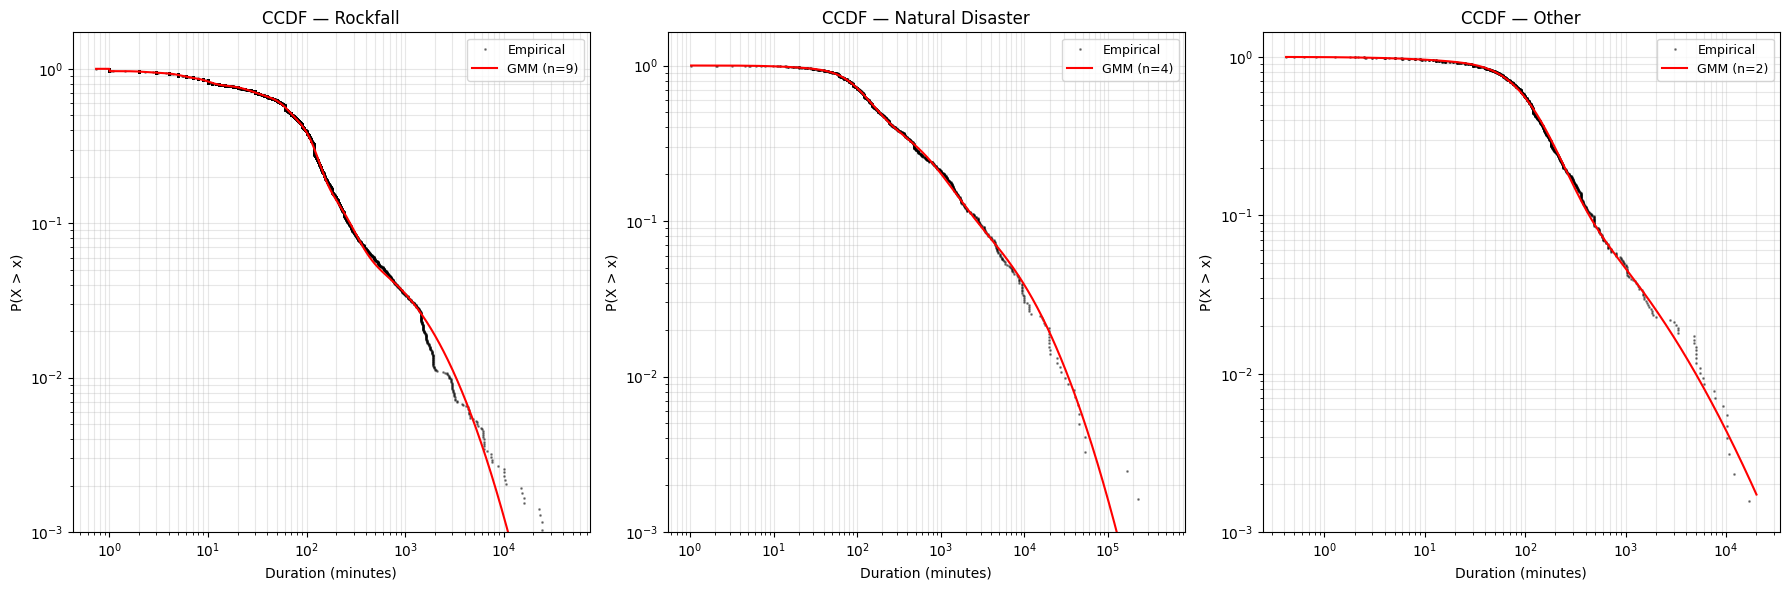

In [197]:
from scipy.stats import norm

def gmm_ccdf(gmm, x_grid):
    """
    解析式計算 GMM 在原始空間的 CCDF。
    GMM 對 log(Duration) 建模，故：
        P(X > x) = 1 - sum_k( w_k * Phi((ln(x) - mu_k) / sigma_k) )
    """
    log_x   = np.log(x_grid)                      
    weights = gmm.weights_.flatten()           
    means   = gmm.means_.flatten()          
    stds    = np.sqrt(gmm.covariances_.flatten())   
    cdf = np.sum(
        weights[None, :] * norm.cdf(
            (log_x[:, None] - means[None, :]) / stds[None, :]
        ),
        axis=1
    )
    return 1 - cdf                                


fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, cause in enumerate(causes_fit):
    gmm  = gmm_results[cause]["gmm"]
    n    = gmm.n_components

    # 實際資料 CCDF
    data = np.sort(df[df["Cause"] == cause]["Duration (minutes)"].values)
    ccdf_emp = 1 - np.arange(1, len(data) + 1) / len(data)

    # 解析式 GMM CCDF（log-space 均勻格點）
    x_grid   = np.logspace(np.log10(data.min()), np.log10(data.max()), 1000)
    ccdf_gmm = gmm_ccdf(gmm, x_grid)

    ax = axes[i]
    ax.loglog(data,   ccdf_emp, "k.", markersize=2, alpha=0.4, label="Empirical")
    ax.loglog(x_grid, ccdf_gmm, "r-", linewidth=1.5, label=f"GMM (n={n})")
    ax.set_ylim(bottom=1e-3)
    ax.set_title(f"CCDF — {cause}")
    ax.set_xlabel("Duration (minutes)")
    ax.set_ylabel("P(X > x)")
    ax.legend(fontsize=9)
    ax.grid(True, which="both", alpha=0.3)

    

plt.tight_layout()
plt.show()

# 7. 相對誤差評估

 GMM 擬合結果進行相對誤差評估，主要分析項目如下：

* **7.1 逐點 CCDF 相對誤差**： 逐點計算實際 CCDF 與 GMM 理論 CCDF 的相對誤差，得出整體擬合品質統計與離散化分布
* **7.2 離散化相對誤差表現** : 針對各分位數的相對誤差進行累積數量評估，分級標準為 [< 5% 非常好, 5 ~ 10% 良好, 10 ~ 20% 尚可, > 20% 偏差]


> **GMM CCDF 精確計算方式**：GMM 對 log(Duration) 建模，CCDF 在原始空間為加權常態 CDF 的加總 ：
>
> $$P(X > x) = 1 - \sum_{k=1}^{K} \pi_k \cdot \Phi\!\left(\frac{\ln x - \mu_k}{\sigma_k}\right)$$

## 7.1 逐點 CCDF 相對誤差

* **原理**

  對每個資料點 $x_i$，計算實際 CCDF 與 GMM 估計 CCDF 之間的相對誤差：

  $$\text{Relative Error} = \frac{|P_{\text{empirical}}(X > x_i) - P_{\text{GMM}}(X > x_i)|}{P_{\text{empirical}}(X > x_i)}$$


In [198]:
from scipy.stats import norm as sp_norm

# GMM CCDF 計算
def gmm_ccdf_at(x_vals, gmm):
    """
    對 log-space GMM 在 x_vals (分鐘) 計算精確超越機率 CCDF = 1 - CDF
    """
    # 對輸入進來的資料取對數
    log_x = np.log(np.asarray(x_vals, dtype=float))

    # 建立對應長度的陣列
    cdf = np.zeros(len(log_x))
    
    # 所有族群的機率貢獻
    for k in range(gmm.n_components):
        mu_k    = gmm.means_[k, 0]
        sigma_k = np.sqrt(gmm.covariances_[k, 0, 0])
        cdf    += gmm.weights_[k] * sp_norm.cdf((log_x - mu_k) / sigma_k)
    return 1.0 - cdf

# 一般統計
print("── 相對誤差分布（一般統計）──")
for cause in causes_fit:
    # 先將資料依據修復時長排序
    data = np.sort(df[df["Cause"] == cause]["Duration (minutes)"].values)
    # 資料總數
    n    = len(data)

    # 點位實際發生機率
    ccdf_empirical = 1 - np.arange(1, n + 1) / n
    # GMM 估計值
    ccdf_gmm_vals  = gmm_ccdf_at(data, gmm_results[cause]["gmm"])


    mask       = ccdf_empirical > 0
    ccdf_emp_v = ccdf_empirical[mask]
    ccdf_gmm_v = ccdf_gmm_vals[mask]

    # 計算相對誤差
    rel_err = np.abs(ccdf_emp_v - ccdf_gmm_v) / ccdf_emp_v

    print(f"\n=== {cause} (n={n}) ===")
    print(f"  中位數相對誤差 : {np.median(rel_err)*100:.2f}%")
    print(f"  平均相對誤差   : {np.mean(rel_err)*100:.2f}%")
    print(f"  最大相對誤差   : {rel_err.max()*100:.2f}%")

── 相對誤差分布（一般統計）──

=== Rockfall (n=7790) ===
  中位數相對誤差 : 0.93%
  平均相對誤差   : 2.24%
  最大相對誤差   : 90.96%

=== Natural Disaster (n=1219) ===
  中位數相對誤差 : 0.88%
  平均相對誤差   : 2.27%
  最大相對誤差   : 82.85%

=== Other (n=1280) ===
  中位數相對誤差 : 1.56%
  平均相對誤差   : 2.97%
  最大相對誤差   : 121.05%


## 7.2 離散化相對誤差表現

**誤差判斷標準**

  | 誤差範圍 | 評估 |
  |---------|------|
  | < 5% | 擬合非常好 |
  | 5 ~ 10% | 擬合良好，可接受 |
  | 10 ~ 20% | 擬合尚可，需注意偏離區間 |
  | > 20% | 擬合較差，分布假設可能不適用 |

In [199]:
# 離散化統計
bins_err   = [(0, 0.05), (0.05, 0.10), (0.10, 0.20), (0.20, np.inf)]
labels_err = ["< 5%（非常好）", "5 ~ 10%（良好）", "10 ~ 20%（尚可）", "> 20%（偏差）"]

for cause in causes_fit:
    data = np.sort(df[df["Cause"] == cause]["Duration (minutes)"].values)
    n    = len(data)

    ccdf_empirical = 1 - np.arange(1, n + 1) / n
    ccdf_gmm_vals  = gmm_ccdf_at(data, gmm_results[cause]["gmm"])

    mask    = ccdf_empirical > 0
    rel_err = np.abs(ccdf_empirical[mask] - ccdf_gmm_vals[mask]) / ccdf_empirical[mask]

    rows       = []
    cumulative = 0.0
    for (lo, hi), label in zip(bins_err, labels_err):
        cnt  = int(((rel_err >= lo) & (rel_err < hi)).sum())
        pct  = cnt / len(rel_err) * 100
        cumulative += pct
        rows.append({"誤差區間": label, "點數": cnt,
                     "比例 (%)": round(pct, 1), "累積比例 (%)": round(cumulative, 1)})

    err_table = pd.DataFrame(rows).set_index("誤差區間")
    pct_10 = (rel_err < 0.10).mean() * 100
    pct_20 = (rel_err < 0.20).mean() * 100

    print(f"\n=== {cause} ===")
    display(err_table)


=== Rockfall ===


,點數,比例 (%),累積比例 (%)
誤差區間,,,
< 5%（非常好）,7189,92.3,92.3
5 ~ 10%（良好）,429,5.5,97.8
10 ~ 20%（尚可）,36,0.5,98.3
> 20%（偏差）,135,1.7,100.0



=== Natural Disaster ===


,點數,比例 (%),累積比例 (%)
誤差區間,,,
< 5%（非常好）,1093,89.7,89.7
5 ~ 10%（良好）,89,7.3,97.0
10 ~ 20%（尚可）,16,1.3,98.4
> 20%（偏差）,20,1.6,100.0



=== Other ===


,點數,比例 (%),累積比例 (%)
誤差區間,,,
< 5%（非常好）,1048,81.9,81.9
5 ~ 10%（良好）,200,15.6,97.6
10 ~ 20%（尚可）,15,1.2,98.7
> 20%（偏差）,16,1.3,100.0


# 8. 存檔

In [200]:
import json
import os

params_path = os.path.join(DATA_DIR, "road_repair_params.json")

road_params = {}

# 高雄市 Cause 發生比例
road_params["kaohsiung_cause_ratio"] = {
    row["Cause"]: row["Ratio"]
    for _, row in kaohsiung_ratio.iterrows()
}

# 各 Cause GMM 參數
road_params["road"] = {}
for cause in causes_fit:
    gmm = gmm_results[cause]["gmm"]
    road_params["road"][cause] = {
        "n_components" : int(gmm.n_components),
        "weights"      : gmm.weights_.tolist(),
        "means"        : gmm.means_.flatten().tolist(),
        "stds"         : np.sqrt(gmm.covariances_.flatten()).tolist(),
    }

with open(params_path, "w") as f:
    json.dump(road_params, f, indent=2, ensure_ascii=False)

print(json.dumps(road_params, indent=2, ensure_ascii=False))

{
  "kaohsiung_cause_ratio": {
    "Other": 0.5775,
    "Natural Disaster": 0.2406,
    "Rockfall": 0.1818
  },
  "road": {
    "Rockfall": {
      "n_components": 9,
      "weights": [
        0.2047016789115322,
        0.0298901285556592,
        0.1117937011706887,
        0.09037186427267416,
        0.06524422121431045,
        0.13644052785291702,
        0.26271261559013187,
        0.0648276823932696,
        0.03401758003881679
      ],
      "means": [
        4.164133125807398,
        0.913623328319837,
        5.4876426633524495,
        2.3124084360209345,
        7.005276532326548,
        3.33761734850409,
        4.784417721578935,
        1.6731725358594798,
        2.441260302872201e-233
      ],
      "stds": [
        0.24334059758859705,
        0.2728229926196526,
        0.3950871931016695,
        0.2046512299588639,
        1.066314662924754,
        0.3468083703617561,
        0.22810414479762312,
        0.19906458697319857,
        0.001
      ]
    },
   

# 9. 小討論

* 本分析屬於統計學還是機器學習？

    機器學習與統計學在許多情境下高度相似，界線並不清晰，但本篇採用的更偏向統計學的方法，理由如下：

    1. 機器學習中的監督式學習，需要以**特徵對應標籤**的方式訓練模型來預測目標值。然而本研究並未提供「發生機率 → 修復時長」或反向的配對資料作為訓練依據——實際上，兩者之間的對應關係本身就是未知的，因此不符合監督式學習的前提。

    2. 本篇的目的是**描述事件的統計現象**：給定觀測資料後，尋找合適的分布加以擬合，以還原實際世界中產生這批資料的內在規律，屬於統計學中的參數估計與模型選擇。

* 也正因為不屬於機器學習的框架，故不以 RMSE、R² 等監督式學習指標來衡量模型表現，而是採用 BIC、Log-likelihood 與 CCDF 相對誤差等統計學上的擬合指標。